<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_17_TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS
## Objective:
Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset.

### Dataset:
The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and the second column represents exchange rates USD to Australian Dollar.

### Part 1: Data Preparation and Exploration
1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.

2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

### Part 2: Model Building - ARIMA
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.

3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.

4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

### Part 3: Evaluation and Comparison
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.

2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.

### Deliverables:
●	Include visualizations and explanations for the choices and findings at each step.

●	Well-commented Python code that used to conduct the analysis and build the models.

### Assessment Criteria:
●	Accuracy and completeness of the data preparation and exploration steps.

●	Justification for model selection and parameter tuning decisions.

●	Clarity and depth of the analysis in the diagnostics and model evaluation stages.

This assignment offers hands-on experience with real-world data, applying sophisticated time series forecasting methods to predict future currency exchange rates.



# Part 1: Data Preparation and Exploration

## 1.Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('exchange_rate.csv')
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [ ]:
# Load the dataset again, parsing 'date' as datetime and setting it as index
df = pd.read_csv('exchange_rate.csv', parse_dates=['date'], index_col='date', dayfirst=True)

display(df.head())

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


The code reads the `exchange_rate.csv` file and prepares it for time series analysis in a single step.

The parameter `parse_dates=['date']` converts the values in the `date` column from text strings into datetime objects.

The parameter `dayfirst=True` ensures that dates in the source file are interpreted in **DD-MM-YYYY** format, avoiding any ambiguity in date parsing.

The parameter `index_col='date'` sets the `date` column as the DataFrame index, which is essential for efficient time-based operations such as filtering, resampling, trend analysis, and forecasting.

When `display(df.head())` is executed, the first five rows of the DataFrame are shown. Although the original dates in the CSV file may be in **DD-MM-YYYY** format, pandas displays datetime values in its standard **YYYY-MM-DD HH:MM:SS** format. Therefore, the dates seen in the output are the correctly parsed representations of the original dates and do not indicate any change in the actual date values.


### To verify that the date has been parsed correctly and to inspect data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


####In summary, the output clearly shows that 'date' column has been correctly parsed into datetime objects and set as the DataFrame's DatetimeIndex, which is exactly what is required for time series analysis.

## 2.Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

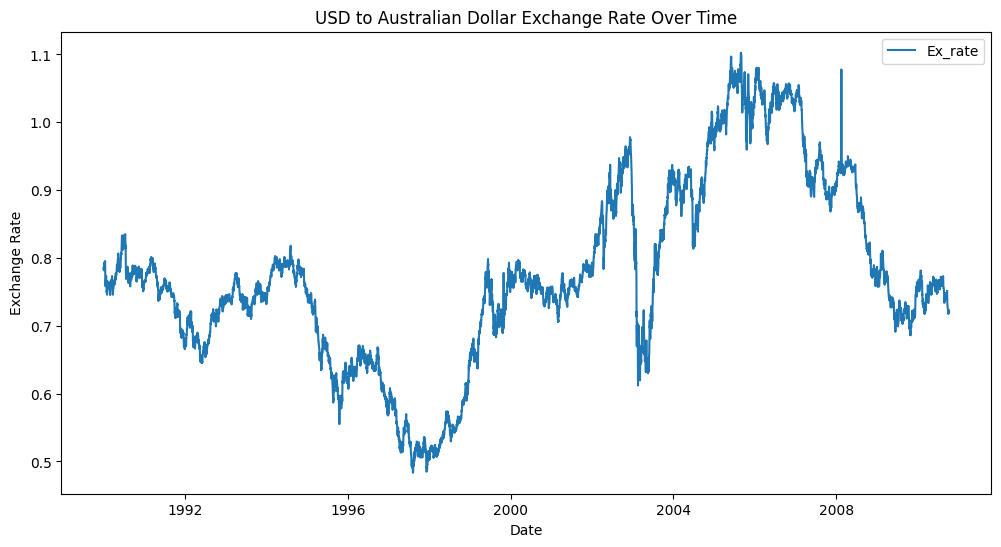

In [ ]:
plt.figure(figsize=(12, 6))
#plt.plot(df) # Uses df.index as the x-axis.Plots all columns of the DataFrame.Creates one line for each column.
# plt.plot(df) behaves as below
for column in df.columns:
    plt.plot(df.index, df[column], label=column)
plt.title('USD to Australian Dollar Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

### Detailed Time Series Component Analysis

Based on the visual inspection of the "USD to Australian Dollar Exchange Rate Over Time" plot (from 1990 to 2010):

*   **Trend**: There is a clear **long-term downward trend** visible, indicating that the value of the USD generally decreased relative to the Australian Dollar over this 20-year period. However, this trend is not monotonic and includes significant upward and downward movements within the overall decline.

*   **Seasonality**: The plot **does not exhibit a clear, consistent seasonal pattern**. Given the daily frequency, one might look for daily, weekly, or monthly patterns, but visually, these are not pronounced. The fluctuations appear more irregular than seasonally driven.

*   **Cyclicity**: The plot shows **cyclical patterns**, which are longer-term fluctuations that are not fixed in their period or amplitude, unlike seasonality. There are periods of several years where the exchange rate is relatively stable or moves in a particular direction before reversing. For instance, there's a decline in the early 1990s, a period of relative stability, another decline around the early 2000s, followed by some recovery and then further drops. These are irregular cycles rather than strict seasonal repetitions.

*   **Noise**: There is **inherent noise** in the data, manifested as small, random, and unpredictable fluctuations around the underlying trend and cyclical components. This noise is common in financial time series and represents the short-term, irregular variations that are difficult to explain with systematic patterns.

*  **Stationarity**: The exchange rate series appears non-stationary, as it exhibits a clear long-term trend and changing mean over time. Since stationarity requires constant statistical properties such as mean and variance, the series likely needs differencing to achieve stationarity before applying ARIMA models.


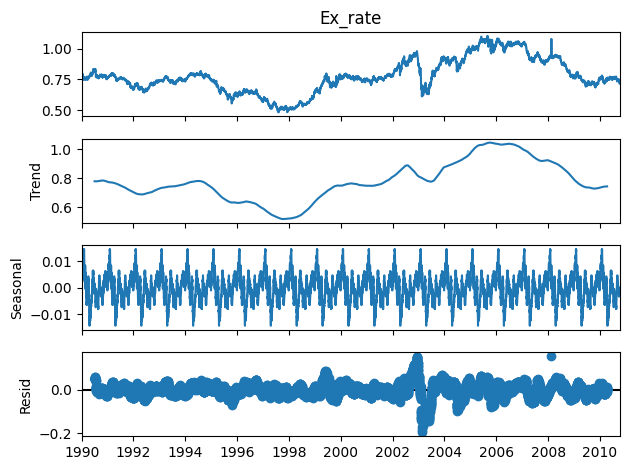

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Ex_rate'], model='additive', period=365)

result.plot()
plt.show()

The decomposition plot indicates that the exchange rate series is dominated by a strong long-term trend and irregular fluctuations. The seasonal component is relatively weak, suggesting the absence of significant yearly seasonality. The residual component captures random variations and market shocks, particularly around 2003–2004. Overall, the series appears to be influenced more by trend and cyclical economic factors than by seasonal effects.

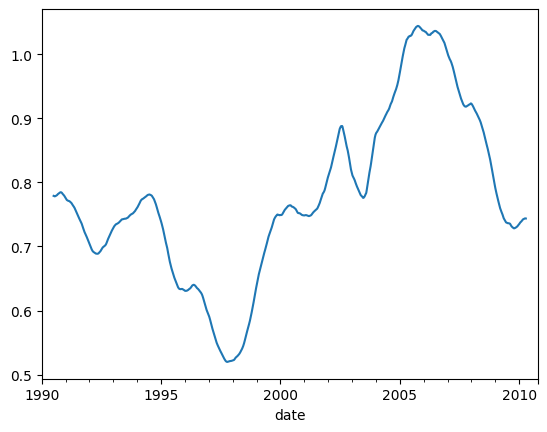

In [ ]:
result.trend.plot()
plt.show()

The trend component highlights the long-term movement of the USD/AUD exchange rate over the study period. The exchange rate declined during the mid-1990s, rose steadily to a peak around 2006–2007, and then declined thereafter. These broad fluctuations indicate the presence of cyclical economic influences and confirm that the series exhibits a changing mean over time, suggesting non-stationarity.

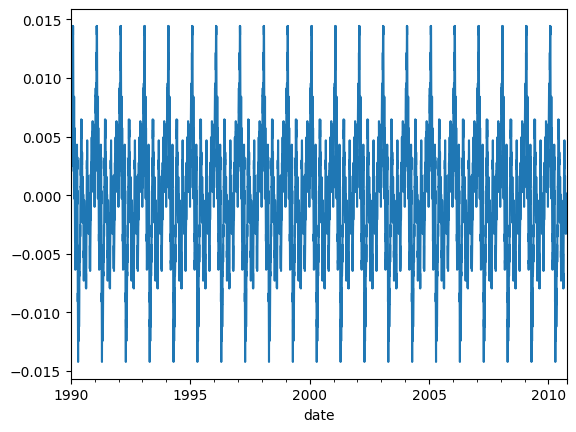

In [ ]:
result.seasonal.plot()
plt.show()

The seasonal component displays a repeating pattern with relatively small amplitude throughout the period. Since the fluctuations are minor compared to the overall movement of the exchange rate, seasonality appears weak and contributes little to the long-term behavior of the series. This suggests that trend and cyclical factors have a much greater influence on exchange rate movements than seasonal effects.

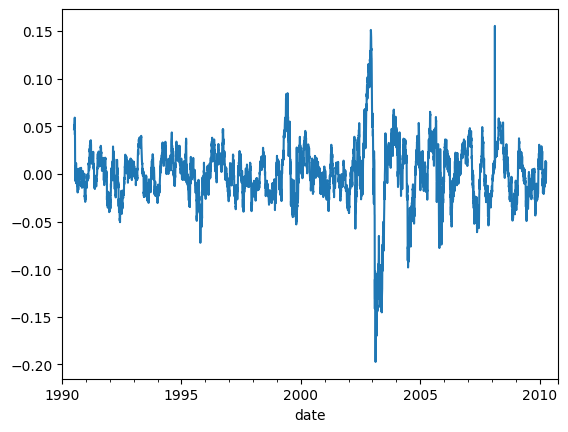

In [ ]:
result.resid.plot()
plt.show()

The residual component represents the irregular or random fluctuations remaining after removing the trend and seasonal effects. The residuals are centered around zero, indicating that most systematic patterns have been captured by the decomposition. However, several large spikes, particularly around 2003–2004 and 2008, suggest the occurrence of unexpected market shocks or periods of heightened volatility.

### (HP) filter
The decomposition analysis revealed a strong trend component, weak seasonality, and noticeable irregular fluctuations in the exchange rate series. However, it does not explicitly isolate cyclical movements, which are important for understanding medium- to long-term economic fluctuations. Therefore, the Hodrick–Prescott (HP) filter is applied to separate the series into trend and cyclical components, enabling a clearer analysis of underlying cyclical behavior in the USD/AUD exchange rate.

In [ ]:
from statsmodels.tsa.filters.hp_filter import hpfilter

cycle, trend = hpfilter(df['Ex_rate'], lamb=1600)

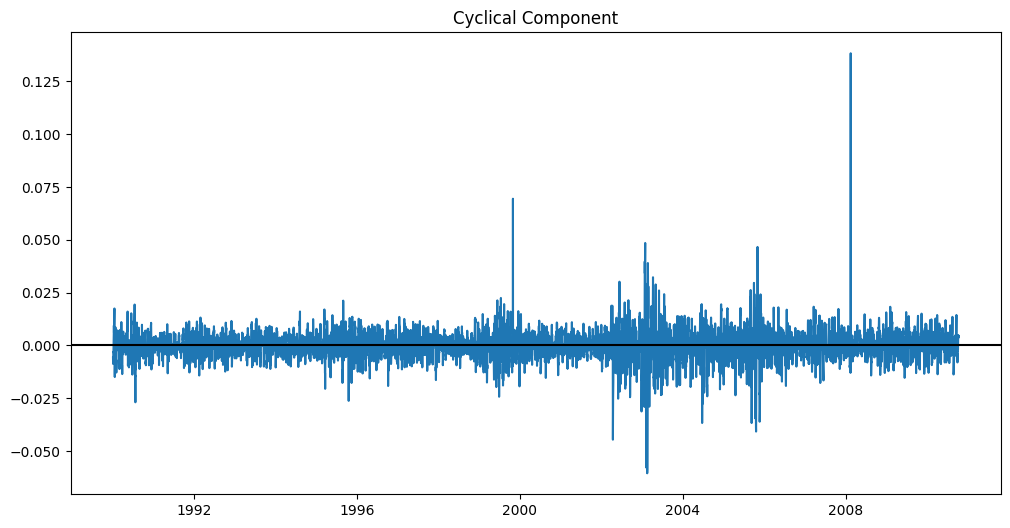

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(cycle)
plt.axhline(0, color='black')
plt.title('Cyclical Component')
plt.show()

The cyclical component fluctuates around zero, capturing medium-term deviations from the long-term trend of the USD/AUD exchange rate. While cyclical movements are evident throughout the period, their magnitude is considerably smaller than that of the trend component, indicating that they are not the primary driver of exchange rate behavior. Most fluctuations remain close to zero, reflecting moderate cyclical variation, although a few pronounced positive and negative spikes—particularly around 2000, 2003–2005, and 2008—suggest periods of significant economic or market disturbances. Overall, the series exhibits moderate cyclical behavior, but its long-term movement is dominated by the underlying trend.

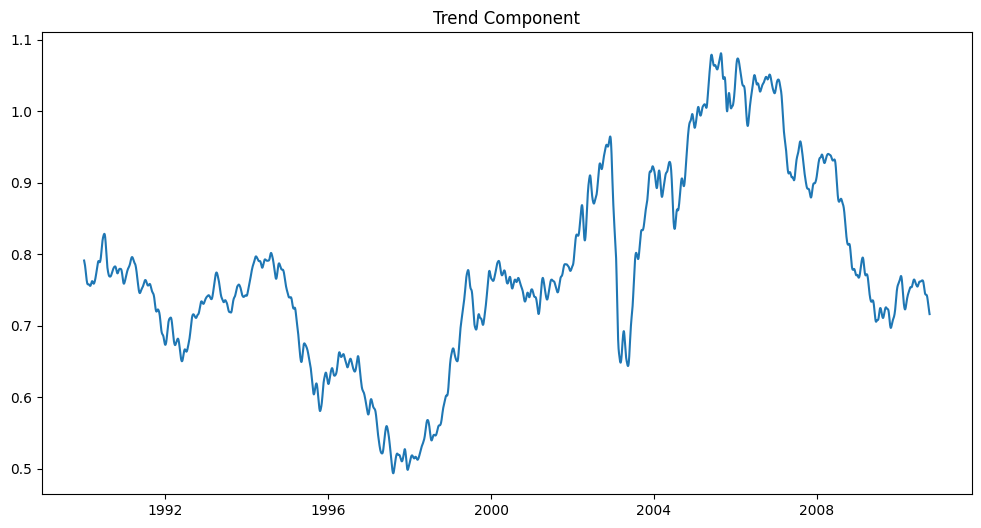

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(trend)
plt.title('Trend Component')
plt.show()

The HP filter trend component closely mirrors the trend obtained from the seasonal decomposition, confirming the presence of a strong long-term movement in the USD/AUD exchange rate. Both methods reveal a decline during the mid-1990s, a sustained rise to a peak around 2005–2007, and a subsequent downward trend. This consistency strengthens the evidence that the series is primarily driven by long-term trend dynamics and exhibits non-stationary behavior.

## 3.Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

### First, checking whether exchange rate data contains missing values and outliers (anomalies).

In [ ]:
df.isnull().sum()

,0
Ex_rate,0


The dataset contains no missing values in the Ex_rate variable. Hence, no missing-value treatment was required prior to analysis.

### Check for Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(2258)

Although 2,258 duplicate values were detected, these represent repeated exchange-rate observations rather than duplicate records. Since repeated exchange rates are common in financial time series, no observations were removed without further verification.

`date` column being the index does not guarantee uniqueness. Pandas allows duplicate index values.

Check whether  date index contains duplicates using:

In [ ]:
df.index.duplicated().sum()

np.int64(0)

The Date index was verified to contain no duplicate entries. Although duplicate exchange-rate values were observed, these represent legitimate repeated market values occurring on different dates and were therefore retained in the dataset. No duplicate records required removal.

### Identify Anomalies / Outliers

A simple method is the IQR approach:

In [ ]:
Q1 = df['Ex_rate'].quantile(0.25)
Q3 = df['Ex_rate'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Ex_rate'] < lower) | (df['Ex_rate'] > upper)]

print(len(outliers))

0


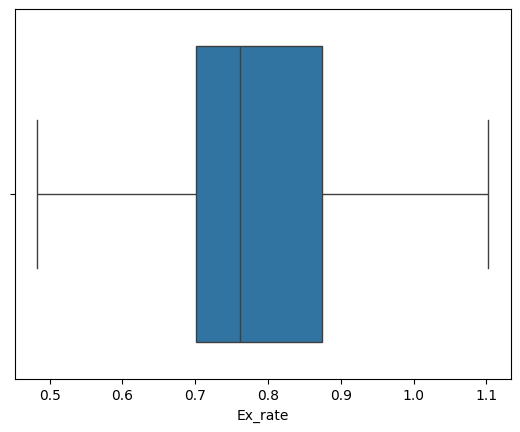

In [ ]:
import seaborn as sns
sns.boxplot(x=df['Ex_rate'])
plt.show()

### The IQR approch shows:  print(len(outliers)) = 0. Means no outliers.

The box plot indicates that the exchange rate values are reasonably well distributed, with a median of approximately 0.76 and no significant outliers. The absence of extreme observations suggests that the dataset does not contain anomalous values requiring treatment prior to time-series modeling.

 ### The absence of extreme observations suggests that the dataset does not contain anomalous values requiring treatment prior to time-series modeling.

# Part 2: Model Building - ARIMA


## 1. Parameter Selection for ARIMA: Utilize ACF and PACF plots to       estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

Before fitting an ARIMA model, the time series must be stationary. Therefore, the stationarity of the exchange rate series will first be examined using rolling mean, rolling standard deviation, and the Augmented Dickey-Fuller (ADF) test. If the series is found to be non-stationary, differencing will be applied until stationarity is achieved. The number of differencing operations required will determine the parameter d of the ARIMA model.

Once a stationary series is obtained, the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots will be generated. These plots will be used to estimate the initial values of the ARIMA parameters p and q. The PACF plot will help identify the order of the Auto-Regressive (AR) component, while the ACF plot will help identify the order of the Moving Average (MA) component.

Based on the stationarity analysis and the ACF/PACF observations, suitable initial values for the parameters (p, d, q) will be selected for constructing the ARIMA model.

### The workflow is:
Check stationarity.

Difference if necessary.

Determine d from the differencing performed.

Plot ACF and PACF of the stationary series.

Determine p and q.

Fit ARIMA(p,d,q).

In [ ]:
# Rolling Mean and Rolling Standard Deviation

def plot_rolling_statistics(series, window=12):

    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()

    plt.figure(figsize=(12,6))

    plt.plot(series, label='Original Series', color='blue')
    plt.plot(rolling_mean, label='Rolling Mean', color='red')
    plt.plot(rolling_std, label='Rolling Std', color='green')

    plt.title('Rolling Mean and Rolling Standard Deviation')
    plt.xlabel('Date')
    plt.ylabel('Exchange Rate')
    plt.legend(loc='best')
    plt.grid(True)

    plt.show()

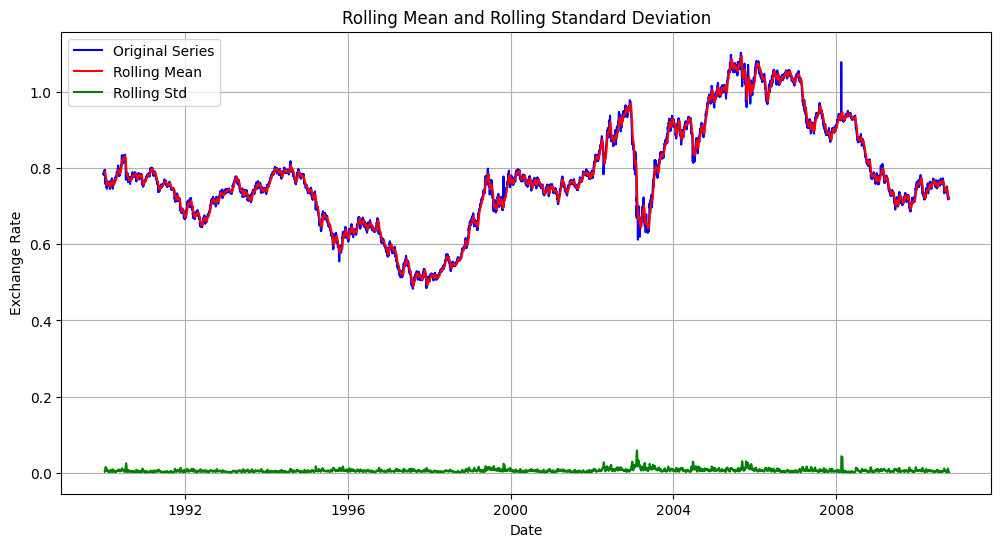

In [ ]:
plot_rolling_statistics(df['Ex_rate'])

### Interpretation - Rolling Mean and Rolling Standard Deviation
Stationarity implies that a time series has a stable mean and variance over time, without significant trends or changes in volatility. The rolling statistics plot shows noticeable variations in both the mean and standard deviation, suggesting that the exchange rate series may not be stationary.

Visual inspection of the rolling statistics indicates that the statistical properties of the series are not entirely stable over time. Therefore, the exchange rate series appears to be non-stationary.

Since rolling statistics provide only a preliminary visual assessment, the Augmented Dickey-Fuller (ADF) test is applied to statistically determine the stationarity of the series. The final conclusion is based on the ADF test results.

### Augmented Dickey-Fuller Test (adfuller)
To statistically verify the stationarity of the exchange rate series, the Augmented Dickey-Fuller (ADF) test is performed. The ADF test examines the presence of a unit root in the series. The null hypothesis states that the series is non-stationary, while the alternative hypothesis states that the series is stationary. The test outputs the ADF statistic, p-value, number of lags used, number of observations, and critical values at different significance levels. If the p-value is less than 0.05 and the ADF statistic is more negative than the critical value, the null hypothesis is rejected, indicating that the series is stationary. Otherwise, the series is considered non-stationary.

In [ ]:
# Augmented Dickey-Fuller Test
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Ex_rate'].dropna())

stats = ['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations','Critical Values','IC Best']
for i in range(len(result)):
    print(f'{stats[i]} : {result[i]}')

Test Statistic : -1.6649941807382342
p-value : 0.4492327353597477
#Lags Used : 1
Number of Observations : 7586
Critical Values : {'1%': np.float64(-3.4312123140180137), '5%': np.float64(-2.861921078147796), '10%': np.float64(-2.5669728434336108)}
IC Best : -55835.06254628545


In [ ]:
# Augmented Dickey-Fuller Test - Decision function

def adf_test(series):

    result = adfuller(series.dropna())

    output = pd.Series(
        result[0:4],
        index=[
            'Test Statistic',
            'p-value',
            'Lags Used',
            'Observations Used'
        ]
    )

    for key, value in result[4].items():
        output[f'Critical Value ({key})'] = value

    print(output)

    print("\nInterpretation")

    if result[1] < 0.05:
        print("Reject H0")
        print("Series is Stationary")
    else:
        print("Fail to Reject H0")
        print("Series is Non-Stationary")

adf_test(df['Ex_rate'])

Test Statistic            -1.664994
p-value                    0.449233
Lags Used                  1.000000
Observations Used       7586.000000
Critical Value (1%)       -3.431212
Critical Value (5%)       -2.861921
Critical Value (10%)      -2.566973
dtype: float64

Interpretation
Fail to Reject H0
Series is Non-Stationary


### Differencing

Differencing is a commonly used transformation for achieving stationarity in a time series. When a series exhibits trends or other forms of non-stationarity, the differences between consecutive observations are computed instead of using the original values. In this analysis, first-order differencing is applied using df['Ex_rate'].diff(), which calculates the change between successive exchange rate values. This process helps remove trend components and stabilize the mean of the series, making it more suitable for time series modeling.

If the differenced series remains non-stationary, higher-order differencing can be applied by differencing the already differenced series. The order of differencing is increased until stationarity is achieved, as confirmed through rolling statistics and the Augmented Dickey-Fuller (ADF) test. In practice, first-order differencing is sufficient for most applications.

In the ARIMA framework, the differencing order is represented by the parameter d, where d = 0 indicates that the original series is already stationary, d = 1 indicates that first-order differencing is required, and d = 2 indicates that second-order differencing is necessary to achieve stationarity. After differencing, the transformed series is re-evaluated using rolling statistics and the ADF test to verify that stationarity has been attained.

In [ ]:
df_diff1 = df['Ex_rate'].diff().dropna()
display(df_diff1.head())

,Ex_rate
date,
1990-01-02,-0.0037
1990-01-03,0.0049
1990-01-04,-0.0007
1990-01-05,-0.0011
1990-01-06,0.0017


### Interpretation of differencing:
First-order differencing was applied using df['Ex_rate'].diff(), which computes the change in exchange rate between consecutive observations. As a result, the original exchange rate values are transformed into period-to-period changes. For example, on 1990-01-02, the exchange rate decreased by 0.0037 compared to the previous day, while on 1990-01-03, it increased by 0.0049. The .dropna() method removed the initial missing value created by the differencing operation. This transformed series is expected to have a more stable mean and is subsequently tested for stationarity using rolling statistics and the ADF test.

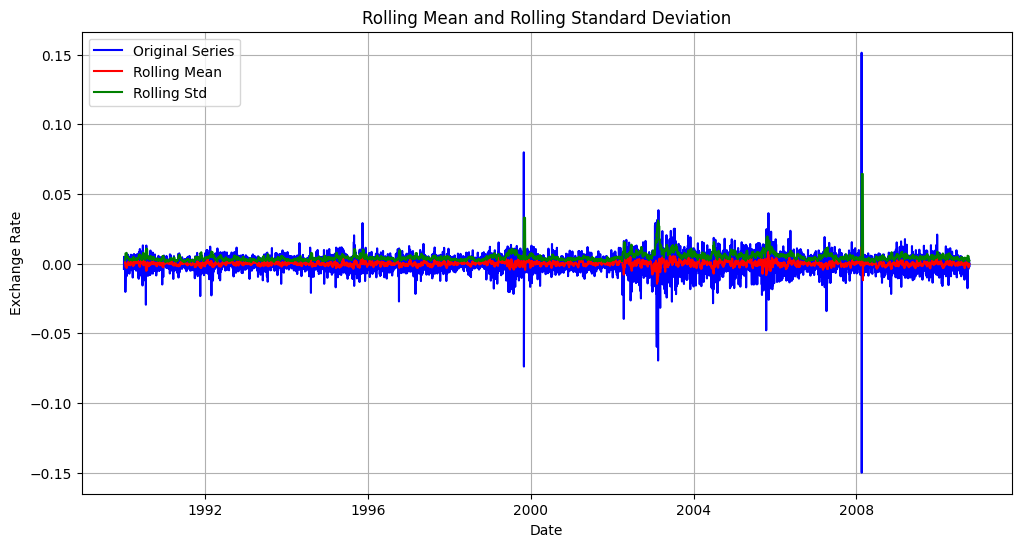

In [ ]:
# Plotting rolling statistics for the differenced series
plot_rolling_statistics(df_diff1)

### interpretation of differenced series plot
The first-order differencing has substantially improved the stationarity of the exchange rate series. The rolling mean remains close to zero and the rolling standard deviation is relatively stable over time, indicating that the trend component has been effectively removed. Although a few isolated volatility spikes are present, the differenced series appears considerably more stationary than the original series. The Augmented Dickey-Fuller (ADF) test is subsequently used to statistically confirm stationarity.

In [ ]:
# Running ADF test on the differenced series
adf_test(df_diff1)

Test Statistic           -99.393431
p-value                    0.000000
Lags Used                  0.000000
Observations Used       7586.000000
Critical Value (1%)       -3.431212
Critical Value (5%)       -2.861921
Critical Value (10%)      -2.566973
dtype: float64

Interpretation
Reject H0
Series is Stationary


### ADF Test Interpretation:
The Augmented Dickey-Fuller (ADF) test on the first-order differenced series produced a test statistic of -99.3934 and a p-value of 0.0000. Since the p-value is well below the 5% significance level (0.05), the null hypothesis of a unit root is rejected. Furthermore, the ADF test statistic is much lower than the critical values at the 1%, 5%, and 10% significance levels, providing strong evidence against non-stationarity. Therefore, the differenced exchange rate series is stationary.

##  Next Steps:
The stationarity analysis confirms that the original exchange rate series was non-stationary and that first-order differencing successfully transformed it into a stationary series. Both the rolling statistics and the Augmented Dickey-Fuller (ADF) test support this conclusion, indicating that the appropriate differencing order for ARIMA modeling is d = 1. Having established stationarity, the next step is to identify the autoregressive (p) and moving average (q) components of the model by examining the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots. These parameters will then be used to build and evaluate an appropriate ARIMA model for forecasting the exchange rate series.

<Figure size 1000x400 with 0 Axes>

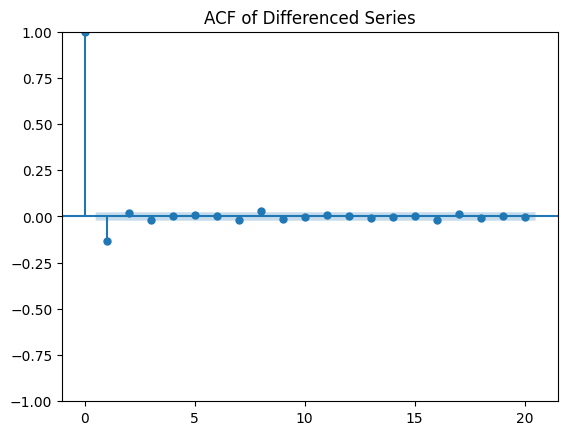

<Figure size 1000x400 with 0 Axes>

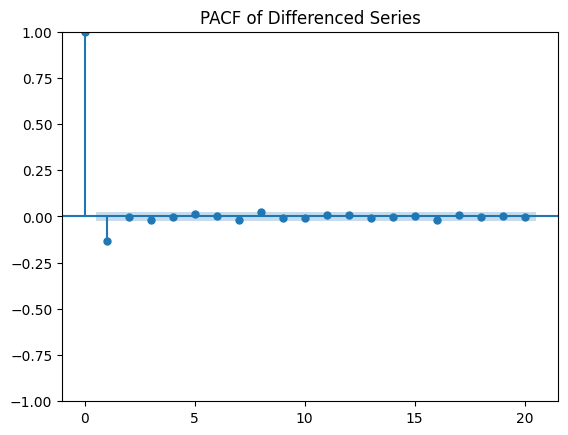

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ACF Plot
plt.figure(figsize=(10, 4))
plot_acf(df_diff1, lags=20)
plt.title('ACF of Differenced Series')
plt.show()

# PACF Plot
plt.figure(figsize=(10, 4))
plot_pacf(df_diff1, lags=20, method='ywm')
plt.title('PACF of Differenced Series')
plt.show()

## Looking at both the ACF and PACF plots:

### ACF
Significant spike only at Lag 1.

All subsequent lags are very close to zero.

The ACF effectively cuts off after Lag 1.

Suggestion: q = 1

### PACF
Significant spike only at Lag 1.

Remaining lags are insignificant and close to zero.

The PACF also cuts off after Lag 1.

Suggestion: p = 1

Conclusion

The ACF and PACF plots of the first-order differenced series both exhibit a significant spike at Lag 1, followed by values that are close to zero for subsequent lags. This pattern suggests the presence of both autoregressive and moving average effects of order one. Therefore, ARIMA(1,1,1) was selected for subsequent modeling and forecasting of the exchange-rate series.

### 2.Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Ex_rate'], order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Sat, 30 May 2026   AIC                         -56102.322
Time:                        23:56:15   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

### The model summary is used to:

1. Assess the significance of AR and MA parameters

The significance of the AR and MA terms is determined from the P>|z| column.

AR(1): ar.L1 = -0.1268, p = 0.005

Since p < 0.05, the AR term is statistically significant and contributes to the model.

MA(1): ma.L1 = -0.0046, p = 0.920

Since p > 0.05, the MA term is not statistically significant and may contribute little to the model.

2. Compare competing ARIMA models using AIC and BIC

The AIC and BIC values are used for model selection.

AIC = -56102.322

BIC = -56081.519

When multiple ARIMA models are fitted, the model with the lowest AIC and BIC is generally preferred, provided it also satisfies the diagnostic checks.

3. Verify whether residuals behave like white noise through diagnostic tests

The Ljung-Box test checks whether significant autocorrelation remains in the residuals.

Prob(Q) = 1.00

Since the p-value is much greater than 0.05, there is no evidence of residual autocorrelation. This suggests that the model has successfully captured the dependence structure present in the series, and the residuals behave approximately as white noise.

4. Determine whether the fitted model is suitable for forecasting

A model is considered suitable for forecasting when:

Significant model parameters are present.

Residuals behave like white noise.

AIC and BIC are reasonably low compared with competing models.

In this case, the residual diagnostics are satisfactory, indicating that the model can be used for forecasting. However, because the MA(1) term is not statistically significant, simpler models such as ARIMA(1,1,0) may also be examined and compared before selecting the final forecasting model.

### 3.Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.



### Diagnostics
#### Purpose
To verify that the residuals contain no remaining information that the model failed to capture.

A good ARIMA model should leave behind only random noise (white noise).

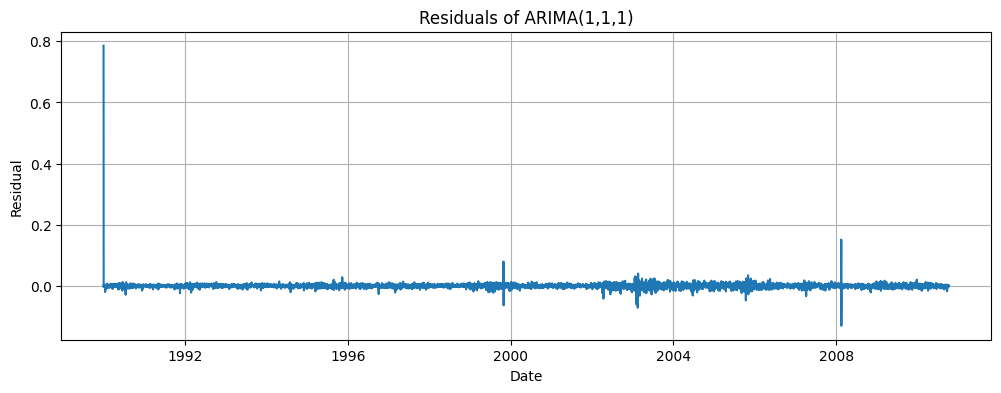

In [ ]:
#Extract Residuals
residuals = model_fit.resid

# Plot Residuals
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title('Residuals of ARIMA(1,1,1)')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

### Interpretation of Residual Plot

The residuals are centered around zero and exhibit no clear trend, seasonality, or systematic pattern over time. Most residual values are small and randomly distributed, indicating that the ARIMA(1,1,1) model has successfully captured the underlying structure of the exchange rate series. Although a few isolated spikes are present, they are infrequent and do not suggest any persistent model inadequacy.

Furthermore, the Ljung-Box test result (Prob(Q) = 1.00) indicates that no significant autocorrelation remains in the residuals. Therefore, the residuals behave approximately as white noise, suggesting that the fitted ARIMA model is adequate and suitable for forecasting.

### 4.Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

### Forecasting

The objective is:

Perform out-of-sample forecasting and visualize the predicted values against the actual values.

In [ ]:
# Split Data into Train and Test Sets

train_size = int(len(df) * 0.8)

train = df['Ex_rate'][:train_size]
test = df['Ex_rate'][train_size:]

In [ ]:
# Fit ARIMA on Training Data
#from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
# Forecast the Test Period
forecast = model_fit.forecast(steps=len(test))

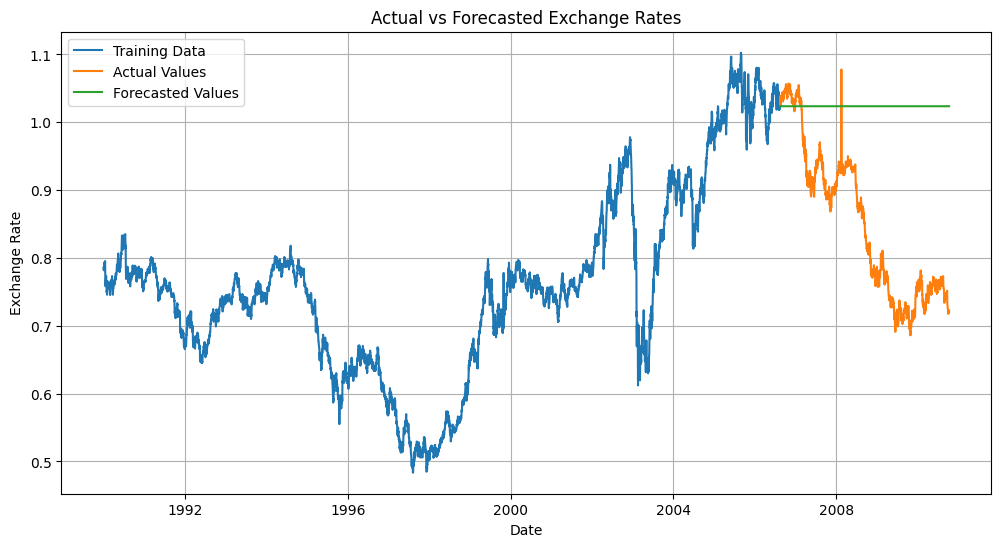

In [ ]:
# Plot Actual vs Forecast
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Values')
plt.plot(test.index, forecast, label='Forecasted Values')

plt.title('Actual vs Forecasted Exchange Rates')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')

plt.legend()
plt.grid(True)

plt.show()

## Exponential Smoothing Model
### Model Fitting

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

es_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

es_fit = es_model.fit()

es_forecast = es_fit.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


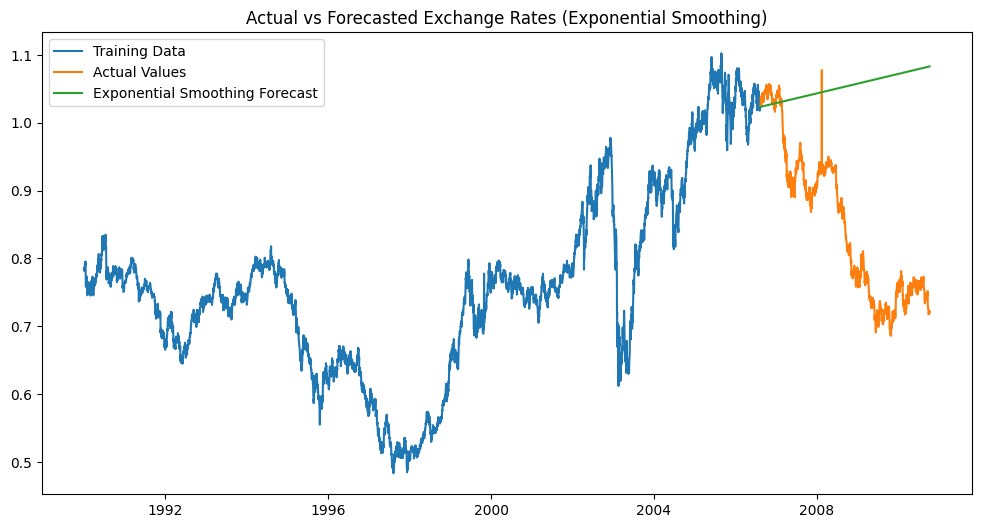

In [ ]:
#Actual vs Forecast Plot
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Values')
plt.plot(test.index, es_forecast,
         label='Exponential Smoothing Forecast')

plt.legend()
plt.title('Actual vs Forecasted Exchange Rates (Exponential Smoothing)')
plt.show()

## Part 3: Evaluation and Comparison
### 1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.

In [ ]:
# Calculate arima Forecast Accuracy

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# ARIMA Forecast Accuracy

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

mape = mean_absolute_percentage_error(
    test,
    forecast
) * 100

print("ARIMA Forecast Accuracy")
print("-----------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape, "%")

ARIMA Forecast Accuracy
-----------------------
MAE  : 0.17770970449121345
RMSE : 0.2054366965966928
MAPE : 22.797966173811552 %


### Forecasting Results interpretation(ARIMA)
The forecasting performance of the ARIMA(1,1,1) model was evaluated using MAE, RMSE, and MAPE. The model achieved an MAE of 0.1777, indicating that the forecasts deviate from the actual exchange rates by an average of approximately 0.18 units. The RMSE of 0.2054 is slightly higher than the MAE, suggesting the presence of some larger forecast errors, although these are not excessive. The MAPE of 22.80% indicates that the forecasts differ from the actual values by about 22.8% on average. Overall, the model demonstrates moderate forecasting accuracy and is capable of capturing the general movement of the exchange-rate series. While the forecasts are reasonably useful for short-term trend estimation, the relatively high MAPE suggests that prediction accuracy could potentially be improved through alternative model specifications or the inclusion of relevant external economic variables


In [ ]:
# # Calculate es Forecast Accuracy

mae_es = mean_absolute_error(test, es_forecast)

rmse_es = np.sqrt(
    mean_squared_error(test, es_forecast)
)

mape_es = (
    mean_absolute_percentage_error(
        test,
        es_forecast
    ) * 100
)

print("MAE :", mae_es)
print("RMSE:", rmse_es)
print("MAPE:", mape_es)

MAE : 0.20659619114093827
RMSE: 0.23910443161792286
MAPE: 26.50866379878783


### Forecasting Results Interpretation (Exponential Smoothing)

The forecasting performance of the Exponential Smoothing model was evaluated using MAE, RMSE, and MAPE. The model achieved an MAE of 0.2066, indicating that the forecasted exchange rates deviate from the actual values by an average of approximately 0.21 units. The RMSE of 0.2391 is slightly higher than the MAE, suggesting the presence of some larger forecast errors, although these are not excessively large. The MAPE of 26.51% indicates that the forecasted values differ from the actual exchange rates by approximately 26.5% on average.

Overall, the Exponential Smoothing model demonstrates moderate forecasting accuracy and is capable of capturing the general movement of the exchange-rate series. The error metrics suggest that the model provides reasonably useful forecasts for short-term trend estimation. However, the MAPE value indicates that there is still considerable forecasting error, implying that the predictive accuracy could potentially be improved through alternative model specifications or more advanced forecasting approaches.

### 2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.



In [ ]:
# Create and format comparison table

comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)'],
    'ARIMA (1,1,1)': [mae, rmse, mape],
    'Exponential Smoothing': [mae_es, rmse_es, mape_es]
})

comparison_df.iloc[:,1:] = comparison_df.iloc[:,1:].round(4)

display(comparison_df)

,Metric,"ARIMA (1,1,1)",Exponential Smoothing
0,MAE,0.1777,0.2066
1,RMSE,0.2054,0.2391
2,MAPE (%),22.7980,26.5087


### Model Comparison

The forecasting performance of the ARIMA(1,1,1) and Exponential Smoothing models was evaluated using MAE, RMSE, and MAPE. The ARIMA model achieved an MAE of 0.1777, RMSE of 0.2054, and MAPE of 22.80%, whereas the Exponential Smoothing model produced an MAE of 0.2066, RMSE of 0.2391, and MAPE of 26.51%. Since lower values of these metrics indicate better forecasting accuracy, the ARIMA model outperformed the Exponential Smoothing model across all evaluation measures.

The superior performance of ARIMA suggests that the exchange-rate series contains autocorrelation patterns that are effectively captured by the autoregressive and moving-average components of the model. In contrast, Exponential Smoothing primarily focuses on level and trend estimation and does not explicitly model the underlying autocorrelation structure of the series.

**Advantages of ARIMA**

Captures temporal dependencies through autoregressive and moving-average terms.

Suitable for non-stationary series after differencing.

Provides statistical diagnostics for model validation.

**Limitations of ARIMA**

Requires stationarity and parameter selection.

Model building and interpretation are relatively more complex.

Long-term forecasts tend to converge toward a stable level.

**Advantages of Exponential Smoothing**

Simple to implement and computationally efficient.

Effective for data with smooth level and trend components.

Requires fewer modeling assumptions.

**Limitations of Exponential Smoothing**

Does not explicitly model autocorrelation.

May be less effective when the series exhibits complex temporal dependencies.

Overall, based on the observed error metrics, ARIMA(1,1,1) provided more accurate forecasts and was the preferred model for forecasting the USD/AUD exchange-rate series.

### Future 30-Day Forecast Using Entire Dataset

In [ ]:

# ARIMA fitted on full dataset
final_arima = ARIMA(df['Ex_rate'], order=(1,1,1))
final_arima_fit = final_arima.fit()

future_forecast = final_arima_fit.forecast(steps=30)

print("ARIMA - Next 30 Day Forecast")
print(future_forecast)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA - Next 30 Day Forecast
2010-10-11    0.720826
2010-10-12    0.720826
2010-10-13    0.720826
2010-10-14    0.720826
2010-10-15    0.720826
2010-10-16    0.720826
2010-10-17    0.720826
2010-10-18    0.720826
2010-10-19    0.720826
2010-10-20    0.720826
2010-10-21    0.720826
2010-10-22    0.720826
2010-10-23    0.720826
2010-10-24    0.720826
2010-10-25    0.720826
2010-10-26    0.720826
2010-10-27    0.720826
2010-10-28    0.720826
2010-10-29    0.720826
2010-10-30    0.720826
2010-10-31    0.720826
2010-11-01    0.720826
2010-11-02    0.720826
2010-11-03    0.720826
2010-11-04    0.720826
2010-11-05    0.720826
2010-11-06    0.720826
2010-11-07    0.720826
2010-11-08    0.720826
2010-11-09    0.720826
Freq: D, Name: predicted_mean, dtype: float64


In [ ]:
# Exponential Smoothing fitted on full dataset
final_es = ExponentialSmoothing(
    df['Ex_rate'],
    trend='add',
    seasonal=None
)

final_es_fit = final_es.fit()

es_future_forecast = final_es_fit.forecast(steps=30)

print("\nExponential Smoothing - Next 30 Day Forecast")
print(es_future_forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



Exponential Smoothing - Next 30 Day Forecast
2010-10-11    0.720852
2010-10-12    0.720843
2010-10-13    0.720835
2010-10-14    0.720826
2010-10-15    0.720818
2010-10-16    0.720809
2010-10-17    0.720801
2010-10-18    0.720792
2010-10-19    0.720784
2010-10-20    0.720775
2010-10-21    0.720767
2010-10-22    0.720758
2010-10-23    0.720750
2010-10-24    0.720741
2010-10-25    0.720733
2010-10-26    0.720724
2010-10-27    0.720716
2010-10-28    0.720707
2010-10-29    0.720699
2010-10-30    0.720691
2010-10-31    0.720682
2010-11-01    0.720674
2010-11-02    0.720665
2010-11-03    0.720657
2010-11-04    0.720648
2010-11-05    0.720640
2010-11-06    0.720631
2010-11-07    0.720623
2010-11-08    0.720614
2010-11-09    0.720606
Freq: D, dtype: float64


### Observation on Future Forecasts

The 30-day forecasts indicate that both models expect the USD/AUD exchange rate to remain relatively stable in the near future. The ARIMA(1,1,1) model produces an almost constant forecast value of approximately 0.7208, suggesting stabilization around a long-run equilibrium level. The Exponential Smoothing model exhibits a slight downward trend in the forecast period, although the predicted values also gradually approach a stable level. Overall, neither model indicates strong upward or downward movements during the forecast period.

## 3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.
This study applied ARIMA and Exponential Smoothing techniques to forecast the USD/AUD exchange rate using historical exchange-rate data. Exploratory analysis revealed that the original series was non-stationary and required first-order differencing to achieve stationarity. The stationarity of the differenced series was confirmed through rolling statistics and the Augmented Dickey-Fuller (ADF) test. Analysis of the ACF and PACF plots suggested an ARIMA(1,1,1) model, which was subsequently fitted to the data and validated through residual diagnostics.

The forecasting performance of both models was evaluated using MAE, RMSE, and MAPE. The ARIMA(1,1,1) model achieved lower forecasting errors (MAE = 0.1777, RMSE = 0.2054, and MAPE = 22.80%) compared with the Exponential Smoothing model (MAE = 0.2066, RMSE = 0.2391, and MAPE = 26.51%). These results indicate that ARIMA provided more accurate forecasts for the exchange-rate series.

Overall, both models were able to capture the general behavior of the USD/AUD exchange rate. However, the superior performance of ARIMA suggests that the exchange-rate series contains temporal dependencies that are more effectively modeled through autoregressive and moving-average components. Therefore, ARIMA(1,1,1) emerged as the most suitable model for forecasting this dataset.

Future studies may further improve forecasting accuracy by incorporating external economic and financial variables through advanced models such as SARIMAX or other multivariate time-series forecasting approaches.
